# GloFAS Nigeria

Downloading for Nigeria here because there is a problem with Anticipy in the other virtualenvs.
I am not sure how to fix it quickly, so just using this installation to download for other countries.

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [135]:
import os
import datetime
from pathlib import Path

import geopandas as gpd
import pandas as pd
import xarray as xr
from tqdm.notebook import tqdm

from ochanticipy import (
    create_country_config,
    CodAB,
    GeoBoundingBox,
    GlofasForecast,
    GlofasReanalysis,
    GlofasReforecast,
)

from src.constants import *

In [4]:
country_config = create_country_config("nga")

In [19]:
DATA_DIR = Path(os.getenv("AA_DATA_DIR"))
CODAB_DIR = DATA_DIR / "public" / "raw" / "nga" / "cod_ab"
AOI_ADM1_PCODES = ["NG008", "NG036", "NG002"]
ADAMAWA = "NG002"


def load_codab(admin_level: int = 0, aoi_only: bool = False):
    filename = f"nga_admbnda_adm{admin_level}_osgof_20190417.shp"
    gdf = gpd.read_file(CODAB_DIR / filename)
    if aoi_only:
        gdf = gdf[gdf["ADM1_PCODE"].isin(AOI_ADM1_PCODES)]
    return gdf


codab = load_codab(admin_level=1, aoi_only=True)
adamawa = codab[codab["ADM1_PCODE"] == ADAMAWA]

<Axes: >

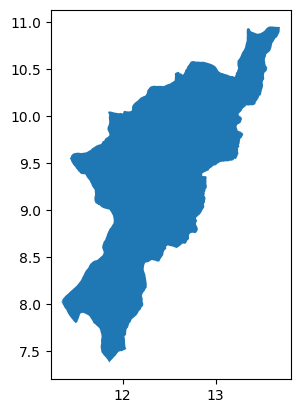

In [20]:
adamawa.plot()

In [21]:
geobb = GeoBoundingBox.from_shape(adamawa)

In [169]:
geobb

N: 10.949461265000025
S: 7.378666047000024
E: 13.692224932000045
W: 11.341521140000054

In [24]:
startdate = datetime.date(1970, 1, 1)
end

In [166]:
forecast = GlofasForecast(
    country_config=country_config,
    geo_bounding_box=geobb,
    leadtime_max=15,
    start_date=datetime.date(2023, 1, 1),
    end_date=datetime.date(2024, 1, 1),
)

In [168]:
reforecast = GlofasReforecast(
    country_config=country_config,
    geo_bounding_box=geobb,
    leadtime_max=15,
    # start_date=startdate,
    # end_date=enddate,
)

In [ ]:
reforecast.download()

In [ ]:
forecast.

In [34]:
reanalysis = GlofasReanalysis(
    country_config=country_config,
    geo_bounding_box=geobb,
    # start_date=startdate,
    # end_date=enddate,
)

In [131]:
df = (
    da.sel(latitude=WUROBOKI_LAT, longitude=WUROBOKI_LON, method="nearest")
    .to_dataframe()
    .reset_index()[["time", "dis24"]]
)
df

,time,dis24
0,1988-01-01,72.375000
1,1988-01-02,70.781250
2,1988-01-03,70.140625
3,1988-01-04,69.562500
4,1988-01-05,69.156250
...,...,...
361,1988-12-27,82.453125
362,1988-12-28,82.109375
363,1988-12-29,81.703125
364,1988-12-30,81.250000


<Axes: xlabel='time'>

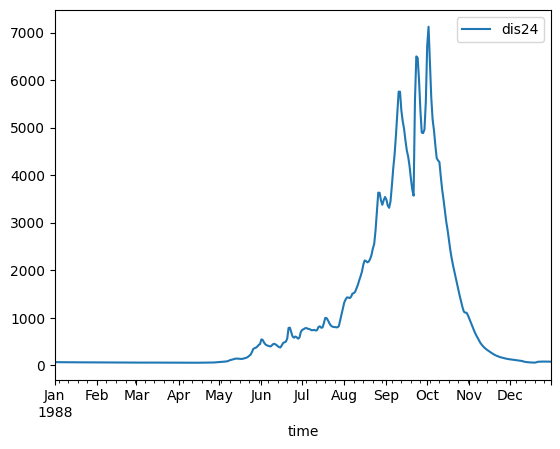

In [123]:
df.plot(x="time", y="dis24")

In [110]:
df

step  surface valid_time      dis24
time       latitude longitude                                      
1988-01-01 9.375    12.825    1 days      0.0 1988-01-02  71.890625
                    12.875    1 days      0.0 1988-01-02  71.625000
           9.325    12.825    1 days      0.0 1988-01-02   0.000000
                    12.875    1 days      0.0 1988-01-02   0.000000
1988-01-02 9.375    12.825    1 days      0.0 1988-01-03  70.640625
...                              ...      ...        ...        ...
1988-12-30 9.325    12.875    1 days      0.0 1988-12-31   0.000000
1988-12-31 9.375    12.825    1 days      0.0 1989-01-01  79.046875
                    12.875    1 days      0.0 1989-01-01  78.671875
           9.325    12.825    1 days      0.0 1989-01-01   0.000000
                    12.875    1 days      0.0 1989-01-01   0.000000

[1464 rows x 4 columns]

In [107]:
da.sel(
    latitude=slice(WUROBOKI_LAT + step, WUROBOKI_LAT - step),
    longitude=slice(WUROBOKI_LON - step, WUROBOKI_LON + step),
).isel(time=0)

<xarray.DataArray 'dis24' (latitude: 4, longitude: 4)>
array([[0.0000000e+00, 6.2500000e-02, 0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 6.2500000e-02, 6.2500000e-02, 0.0000000e+00],
       [0.0000000e+00, 7.2375000e+01, 7.1890625e+01, 7.1625000e+01],
       [7.2453125e+01, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],
      dtype=float32)
Coordinates:
    time        datetime64[ns] 1988-01-01
    step        timedelta64[ns] 1 days
    surface     float64 0.0
  * latitude    (latitude) float64 9.475 9.425 9.375 9.325
  * longitude   (longitude) float64 12.73 12.78 12.83 12.88
    valid_time  datetime64[ns] 1988-01-02
Attributes: (12/29)
    GRIB_paramId:                             240024
    GRIB_dataType:                            sfo
    GRIB_numberOfPoints:                      3825
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avg
    ...                                       ...
    GRIB_name:                                Mean discharge in the last 24 h...
    GRIB_shortName:                           dis24
    GRIB_units:                               m**3 s**-1
    long_name:                                Mean discharge in the last 24 h...
    units:                                    m**3 s**-1
    standard_name:                            unknown

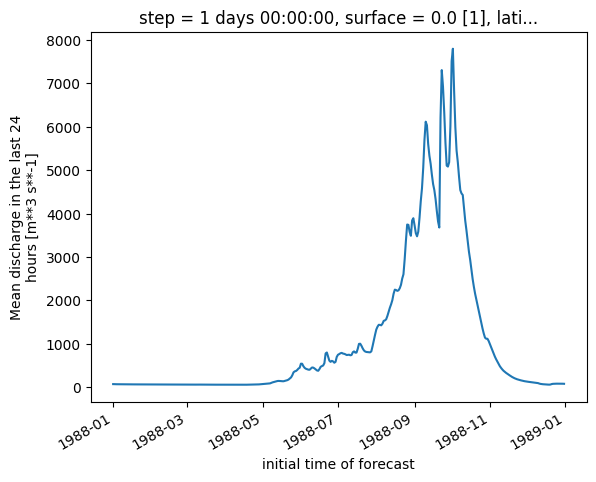

In [108]:
shift = 0
da.sel(
    latitude=WUROBOKI_LAT + shift,
    longitude=WUROBOKI_LON + shift,
    method="nearest",
).plot()

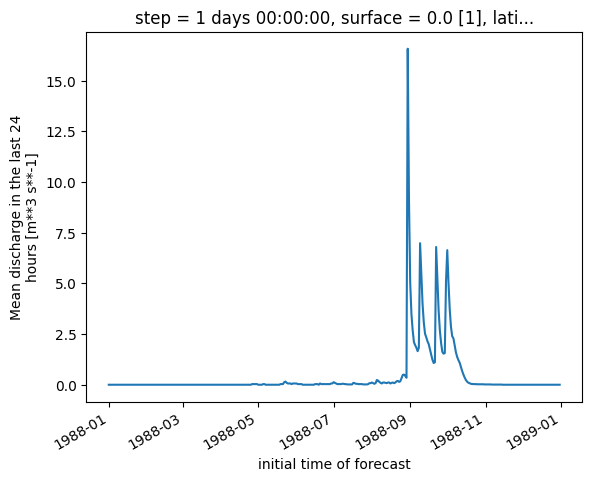

In [63]:
ds.sel(latitude=9.35, longitude=12.75, method="nearest")["dis24"].plot()